# Thesis Figures — Missing Visualizations

Generates 4 new thesis-quality figures + fixed dendrogram, in both French and English.

- **Fig. A:** Heritage divergence — 10 small multiples (Ch.2 S2)
- **Fig. B:** Treaty beeswarm scatter (Ch.2 S1)
- **Fig. C:** Correlation matrix (Ch.2 S2)
- **Fig. D:** Score distribution boxplot (Ch.2 S2)
- **Fig. E:** Fixed dendrogram — horizontal (Ch.2 S2)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'scripts'))
from figure_style import *
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

apply_style()
DATA = load_data()

# Build feature matrix
fm = pd.DataFrame(DATA['feature_matrix'])
fm['heritage'] = fm['PAYS'].map(DATA['colonial_heritage'])
fm['post_conflict'] = fm['PAYS'].map(DATA['post_conflict']).fillna(False)
fm['total_score'] = fm[FEATURES].sum(axis=1)

# Tier 1
tier1 = fm[fm['heritage'].isin(['francophone', 'anglophone'])].copy()

print(f'Loaded: {len(fm)} countries, Tier 1: {len(tier1)}')

Loaded: 54 countries, Tier 1: 42


## Figure A: Heritage Divergence — 10 Small Multiples

Left column: identity dimensions (diverge post-1990). Right column: institutional dimensions (converge).

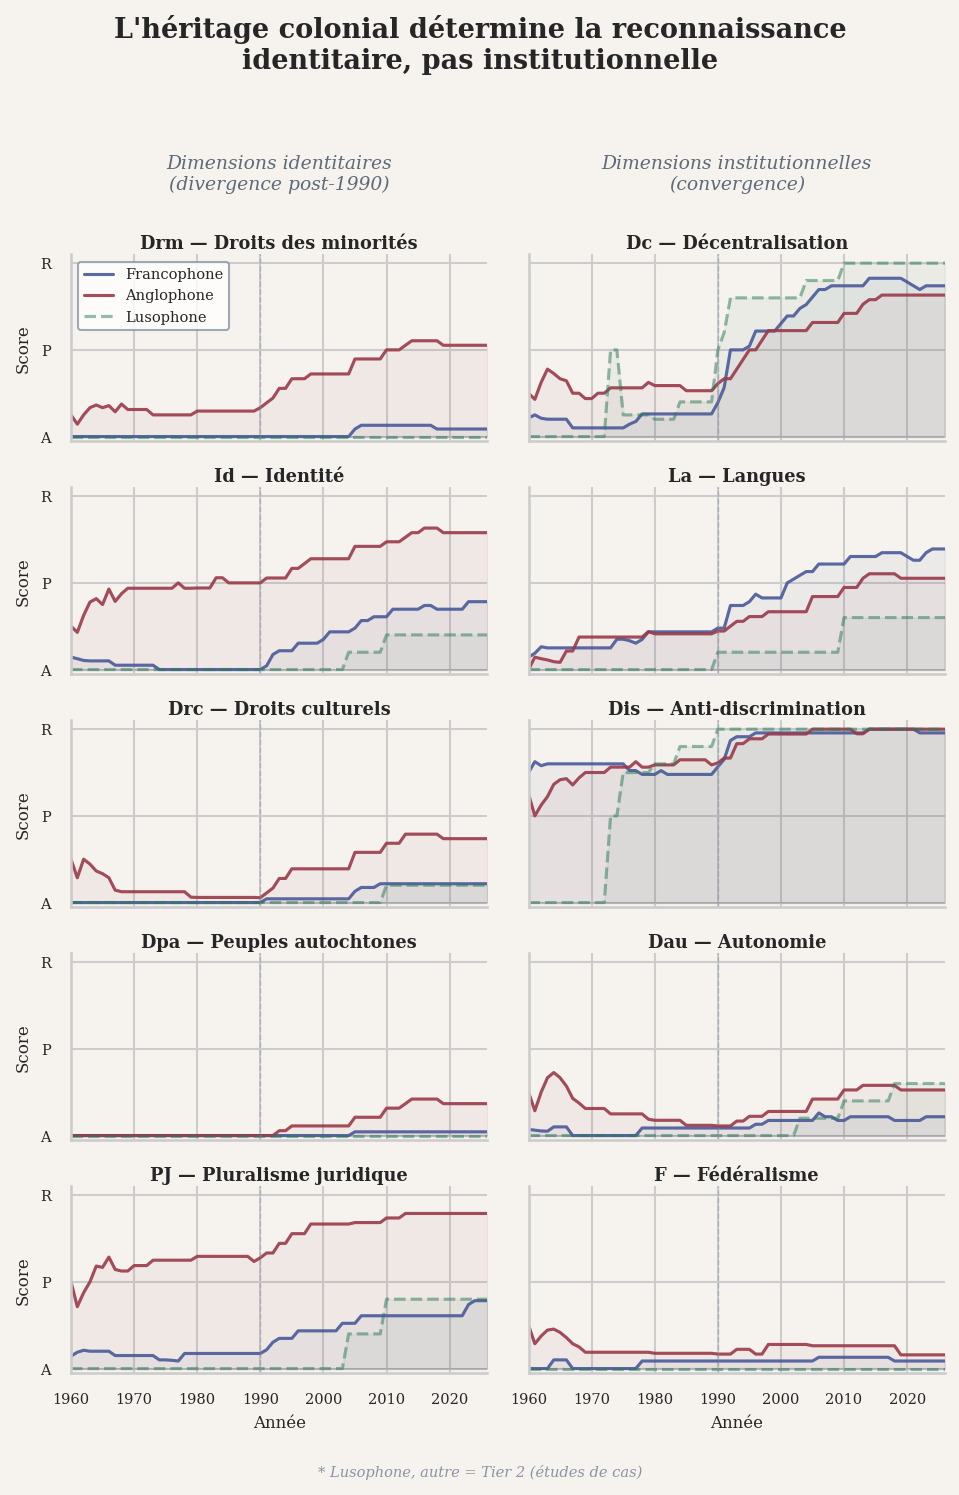

Saved: ch2s2_heritage_divergence (fr + en)


In [2]:
div_data = DATA['heritage_divergence']

# Layout: identity left, institutional right
left_dims = ['Drm', 'Id', 'Drc', 'Dpa', 'PJ']   # identity cluster
right_dims = ['Dc', 'La', 'Dis', 'Dau', 'F']     # institutional/baseline

for lang in ('fr', 'en'):
    fig, axes = plt.subplots(5, 2, figsize=(6.5, 10), sharex=True, sharey=True)
    fig.suptitle(t('heritage_divergence_title', lang), fontsize=13, fontweight='bold',
                 fontfamily='serif', y=0.98)

    for col_idx, (dims, col_label_key) in enumerate([
        (left_dims, 'heritage_divergence_left'),
        (right_dims, 'heritage_divergence_right'),
    ]):
        for row_idx, feat in enumerate(dims):
            ax = axes[row_idx, col_idx]
            dim_data = div_data.get(feat, {})

            for h in ['francophone', 'anglophone', 'lusophone']:
                series = dim_data.get(h, [])
                if series:
                    years = [p[0] for p in series]
                    scores = [p[1] for p in series]
                    ls = '--' if h == 'lusophone' else '-'
                    al = 0.5 if h == 'lusophone' else 0.9
                    ax.plot(years, scores, color=HC[h], linewidth=1.5, alpha=al,
                            linestyle=ls,
                            label=hl(h, lang) if row_idx == 0 and col_idx == 0 else None)
                    ax.fill_between(years, 0, scores, color=HC[h], alpha=0.06)

            # 1990 line
            ax.axvline(1990, color=C_DIM, linestyle='--', linewidth=0.7, alpha=0.5)

            # Panel title
            dim_label = t('dim', lang)[feat]
            ax.set_title(f'{feat} — {dim_label}', fontsize=8.5, fontweight='bold', pad=3)
            ax.set_ylim(-0.05, 2.1)
            ax.set_xlim(1960, 2026)

            if row_idx == 4:
                ax.set_xlabel(t('functional_emergence_xlabel', lang), fontsize=8)
            if col_idx == 0:
                ax.set_ylabel('Score', fontsize=8)

            # Y ticks
            ax.set_yticks([0, 1, 2])
            ax.set_yticklabels([t('absent', lang)[0], t('partial', lang)[0], t('recognized', lang)[0]],
                              fontsize=7)
            ax.tick_params(axis='x', labelsize=7)

        # Column header
        axes[0, col_idx].annotate(t(col_label_key, lang), xy=(0.5, 1.35),
                                  xycoords='axes fraction', ha='center', fontsize=9,
                                  fontstyle='italic', color=C_MUTED)

    # Legend on first panel
    axes[0, 0].legend(fontsize=7, loc='upper left', frameon=True, facecolor='white',
                       edgecolor=C_DIM)

    # Tier 2 footnote for lusophone
    fig.text(0.5, 0.005, t('tier2_note', lang), ha='center', fontsize=7,
             color=C_DIM, style='italic')

    fig.tight_layout(rect=[0, 0.02, 1, 0.96])
    save_fig(fig, 'ch2s2_heritage_divergence', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_heritage_divergence (fr + en)')

## Figure B: Treaty Beeswarm Scatter

Treaty count (x) vs constitutional score (y). Dots by heritage, diamonds for post-conflict.

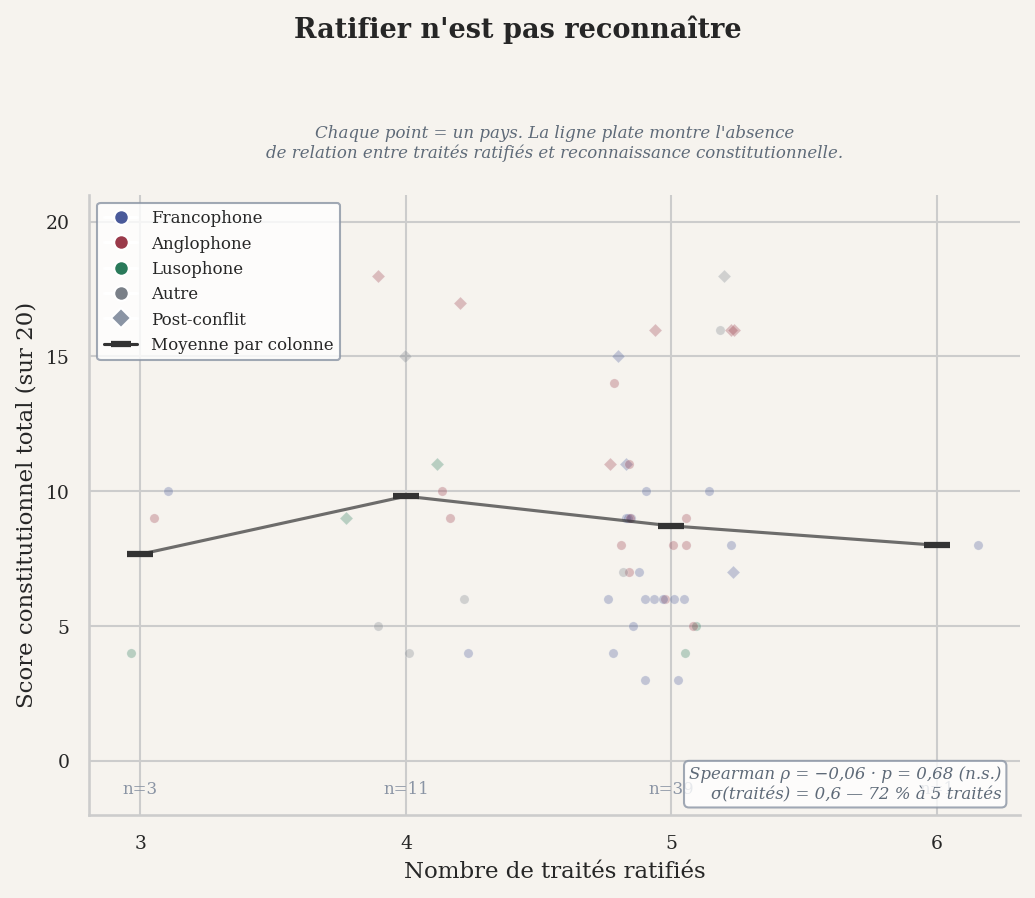

Saved: ch2s1_treaty_beeswarm (fr + en)


In [3]:
# Compute treaty counts
treaties = DATA['treaties']
ratif = DATA['ratif_data']

fm['treaty_count'] = fm['PAYS'].apply(
    lambda c: sum(1 for tr in treaties if ratif.get(c, {}).get(tr) in ('P', 'V'))
)

# Grand mean score across all countries
grand_mean = fm['total_score'].mean()

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 6))

    # Layer 1: FAINT jittered dots (background)
    np.random.seed(42)
    for _, row in fm.iterrows():
        x = row['treaty_count'] + np.random.uniform(-0.25, 0.25)
        y = row['total_score']
        color = HC.get(row['heritage'], C_DIM)
        marker = 'D' if row['post_conflict'] else 'o'
        ax.scatter(x, y, c=color, marker=marker, s=20, alpha=0.3,
                   edgecolors='white', linewidths=0.3, zorder=2)

    # Layer 2: LARGE BOLD per-column mean markers connected by a flat line
    tc_sorted = sorted(fm['treaty_count'].unique())
    mean_scores = []
    for tc in tc_sorted:
        subset = fm[fm['treaty_count'] == tc]
        mean_score = subset['total_score'].mean()
        mean_scores.append(mean_score)
        # Large horizontal bar marker for the mean
        ax.scatter(tc, mean_score, marker='_', s=150, linewidths=3,
                   color='#333333', zorder=5)
        # Count label below x-axis
        ax.text(tc, -1.2, f'n={len(subset)}', ha='center', fontsize=8, color=C_DIM)

    # Connect means with a line — the "flat line = no correlation" message
    ax.plot(tc_sorted, mean_scores, color='#333333', linewidth=1.5, linestyle='-',
            alpha=0.7, zorder=4)

    # Statistical annotation (bottom-right corner only)
    rho, p = spearmanr(fm['treaty_count'], fm['total_score'])
    ax.text(0.98, 0.02, t('treaty_beeswarm_annot', lang),
            transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
            color=C_MUTED, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_DIM, alpha=0.8))

    # Legend
    legend_elements = []
    for h in ['francophone', 'anglophone', 'lusophone', 'other']:
        legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=HC[h],
                                      markersize=7, label=hl(h, lang)))
    legend_elements.append(Line2D([0], [0], marker='D', color='w', markerfacecolor=C_DIM,
                                  markersize=7, label=t('pc_post_conflict', lang)))
    legend_elements.append(Line2D([0], [0], marker='_', color='#333333', markersize=10,
                                  markeredgewidth=3, label='Moyenne par colonne' if lang == 'fr' else 'Column mean'))
    ax.legend(handles=legend_elements, loc='upper left', frameon=True, facecolor='white',
              edgecolor=C_DIM, fontsize=8)

    ax.set_xlabel(t('treaty_beeswarm_xlabel', lang), fontsize=11)
    ax.set_ylabel(t('treaty_beeswarm_ylabel', lang), fontsize=11)

    # Title + subtitle with proper spacing
    fig.suptitle(t('treaty_beeswarm_title', lang), fontsize=13, fontweight='bold',
                 fontfamily='serif', y=0.99)
    ax.set_title(t('treaty_beeswarm_subtitle', lang), fontsize=8, color=C_MUTED,
                 style='italic', pad=18)

    ax.set_ylim(-2, 21)
    ax.set_xticks(sorted(fm['treaty_count'].unique()))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_fig(fig, 'ch2s1_treaty_beeswarm', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s1_treaty_beeswarm (fr + en)')

## Figure C: Correlation Matrix (Tier 1)

Pearson correlations between 10 dimensions, reordered to show the identity cluster in the top-left.

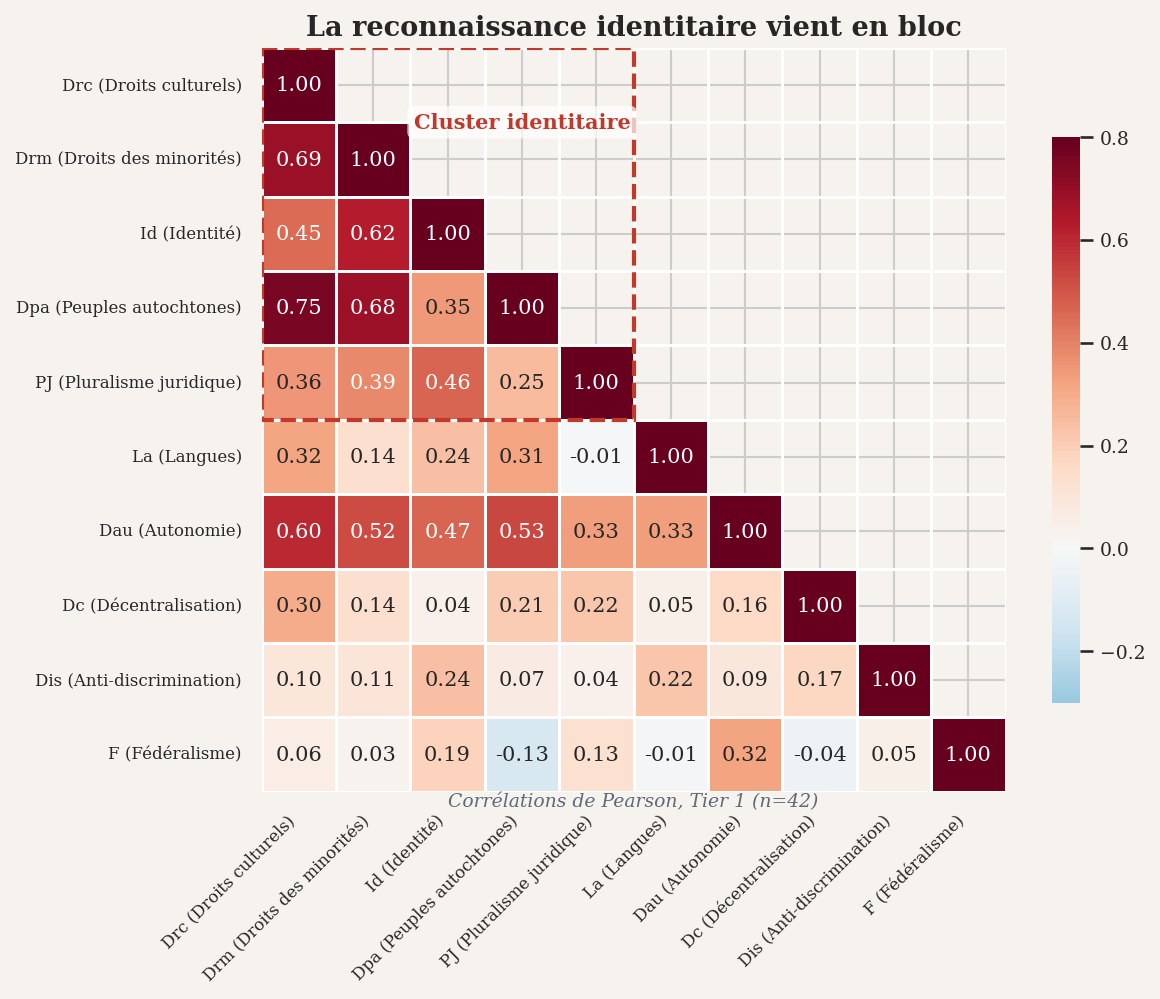

Saved: ch2s2_correlation_matrix (fr + en)


In [4]:
for lang in ('fr', 'en'):
    # Reorder dimensions: identity cluster first
    order = FEATURES_IDENTITY_FIRST
    corr = tier1[order].corr()

    # Labels
    dim_labels = [f'{f} ({t("dim", lang)[f]})' for f in order]

    # Mask upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-0.3, vmax=0.8, square=True, linewidths=0.5,
                xticklabels=dim_labels, yticklabels=dim_labels, ax=ax,
                cbar_kws={'shrink': 0.7})

    ax.set_title(t('correlation_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.text(0.5, -0.02, t('correlation_subtitle', lang), transform=ax.transAxes,
            ha='center', fontsize=9, color=C_MUTED, style='italic')

    # Draw box around identity cluster (first 5 dims)
    n_identity = 5
    rect = plt.Rectangle((0, 0), n_identity, n_identity, fill=False,
                          edgecolor=C_PEOPLES, linewidth=2, linestyle='--')
    ax.add_patch(rect)

    # Label INSIDE the upper-right masked (empty) area of the identity block
    ax.text(3.5, 1.0, t('correlation_cluster_label', lang),
            ha='center', va='center', fontsize=10, fontweight='bold',
            color=C_PEOPLES,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.7))

    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)

    save_fig(fig, 'ch2s2_correlation_matrix', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_correlation_matrix (fr + en)')

## Figure D: Score Distribution by Heritage

Box + strip plot showing the heritage gap. Cohen's d annotated.

/tmp/ipykernel_52472/2979316868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_52472/2979316868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_52472/2979316868.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=9)


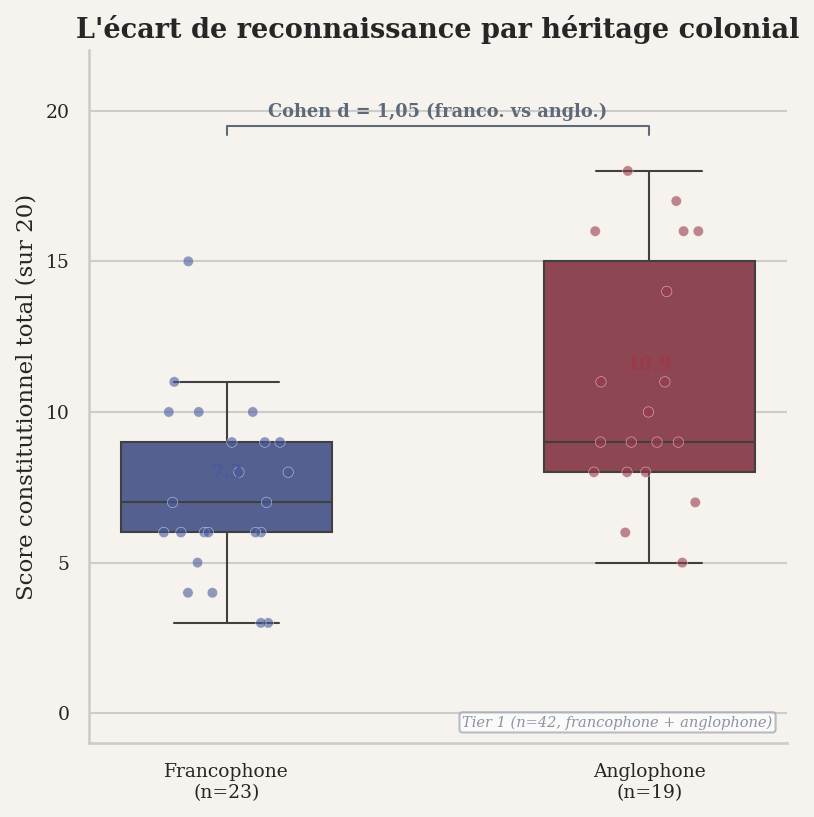

Saved: ch2s2_score_distribution (fr + en)


/tmp/ipykernel_52472/2979316868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_52472/2979316868.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
/tmp/ipykernel_52472/2979316868.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=9)


In [5]:
h_order_2 = ['francophone', 'anglophone']
fm_plot = fm[fm['heritage'].isin(h_order_2)].copy()
fm_plot['heritage'] = pd.Categorical(fm_plot['heritage'], categories=h_order_2, ordered=True)

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(6, 6))

    # Box plot
    palette = {h: HC[h] for h in h_order_2}
    sns.boxplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
                width=0.5, fliersize=0, ax=ax, order=h_order_2)

    # Strip plot overlay
    sns.stripplot(data=fm_plot, x='heritage', y='total_score', palette=palette,
                  size=5, alpha=0.6, jitter=0.15, ax=ax, order=h_order_2,
                  edgecolor='white', linewidth=0.3)

    # Heritage labels
    x_labels = [f'{hl(h, lang)}\n(n={len(fm_plot[fm_plot["heritage"]==h])})' for h in h_order_2]
    ax.set_xticklabels(x_labels, fontsize=9)

    # Mean annotations
    for i, h in enumerate(h_order_2):
        mean_val = fm_plot[fm_plot['heritage'] == h]['total_score'].mean()
        ax.text(i, mean_val + 0.5, f'{mean_val:.1f}', ha='center', fontsize=9,
                fontweight='bold', color=HC[h])

    # Cohen's d bracket
    y_bracket = 19.5
    ax.plot([0, 0, 1, 1], [y_bracket - 0.3, y_bracket, y_bracket, y_bracket - 0.3],
            color=C_MUTED, linewidth=1)
    ax.text(0.5, y_bracket + 0.3, t('score_boxplot_annot', lang),
            ha='center', fontsize=8.5, color=C_MUTED, fontweight='bold')

    ax.set_xlabel('')
    ax.set_ylabel(t('score_boxplot_ylabel', lang), fontsize=11)
    ax.set_title(t('score_boxplot_title', lang), fontsize=13, fontweight='bold', fontfamily='serif')
    ax.set_ylim(-1, 22)

    add_tier_note(ax, lang)

    save_fig(fig, 'ch2s2_score_distribution', lang)
    if lang == 'fr':
        plt.show()
    else:
        plt.close(fig)

print('Saved: ch2s2_score_distribution (fr + en)')

## Figure E: Fixed Dendrogram (Horizontal)

Horizontal orientation with readable labels. Leaves colored by heritage.

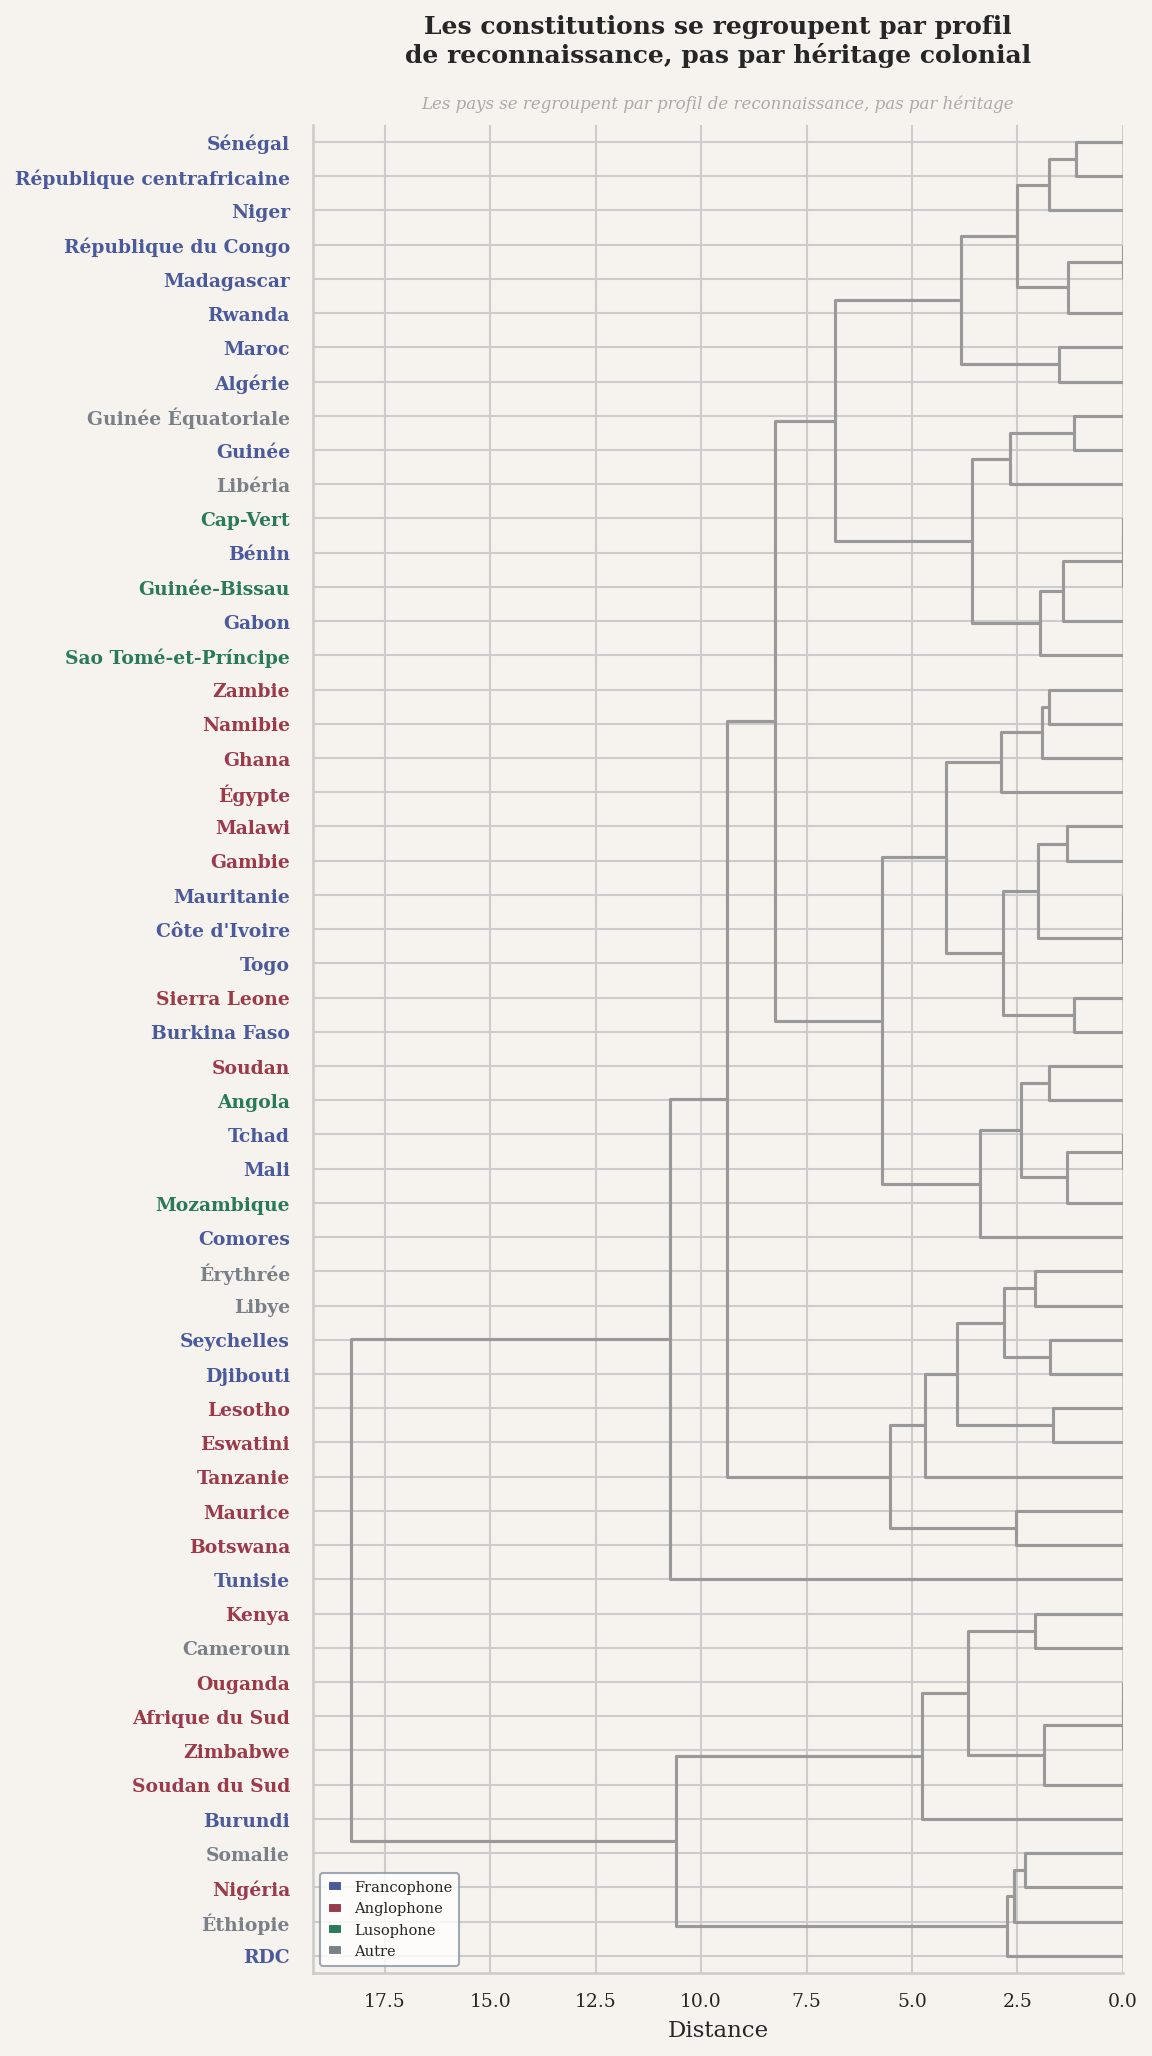

Saved: clusters_dendrogram_dimensions (fr + en)


In [6]:
# Standardize and cluster
X = fm[FEATURES].values
X_scaled = StandardScaler().fit_transform(X)
Z = linkage(X_scaled, method='ward')

from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette(['#999999'])

def _abbrev(name):
    return name.replace('République démocratique du Congo', 'RDC')

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(9, 16))

    dendro = dendrogram(Z, labels=fm['PAYS'].tolist(), orientation='left',
                        leaf_font_size=9, ax=ax, no_labels=True,
                        above_threshold_color='#999999')

    ordered_countries = [fm['PAYS'].tolist()[i] for i in dendro['leaves']]
    ax.set_yticks(range(5, 5 + 10 * len(ordered_countries), 10))
    ax.set_yticklabels([_abbrev(c) for c in ordered_countries], fontsize=9)

    for tick_label, country in zip(ax.get_yticklabels(), ordered_countries):
        h = DATA['colonial_heritage'].get(country, 'other')
        tick_label.set_color(HC.get(h, C_DIM))
        tick_label.set_fontweight('bold')

    ax.tick_params(axis='y', pad=5)
    ax.set_xlim(right=0)
    ax.set_xlabel(t('dendrogram_xlabel', lang), fontsize=11)

    # Title
    ax.set_title(t('dendrogram_title', lang), fontsize=12, fontweight='bold',
                 fontfamily='serif', pad=30)

    # Subtitle (lighter, smaller) — positioned relative to axes top
    ax.annotate(t('dendrogram_subtitle', lang),
                xy=(0.5, 1.0), xycoords='axes fraction',
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color='#aaa', style='italic')

    # Color key as legend box at top-left INSIDE the plot
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=HC['francophone'], label=hl('francophone', lang)),
        Patch(facecolor=HC['anglophone'], label=hl('anglophone', lang)),
        Patch(facecolor=HC['lusophone'], label=hl('lusophone', lang)),
        Patch(facecolor=HC['other'], label=hl('other', lang)),
    ]
    ax.legend(handles=legend_handles, loc='lower left',
              fontsize=7, frameon=True, facecolor='white', edgecolor=C_DIM,
              borderpad=0.5, handlelength=1.0)

    fig.subplots_adjust(left=0.30)
    save_fig(fig, 'clusters_dendrogram_dimensions', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: clusters_dendrogram_dimensions (fr + en)')


## Figure F: Ch.7 — Territorial & Environmental Provisions

Left: land sub-category frequencies by heritage. Right: post-conflict effect on territorial rights.

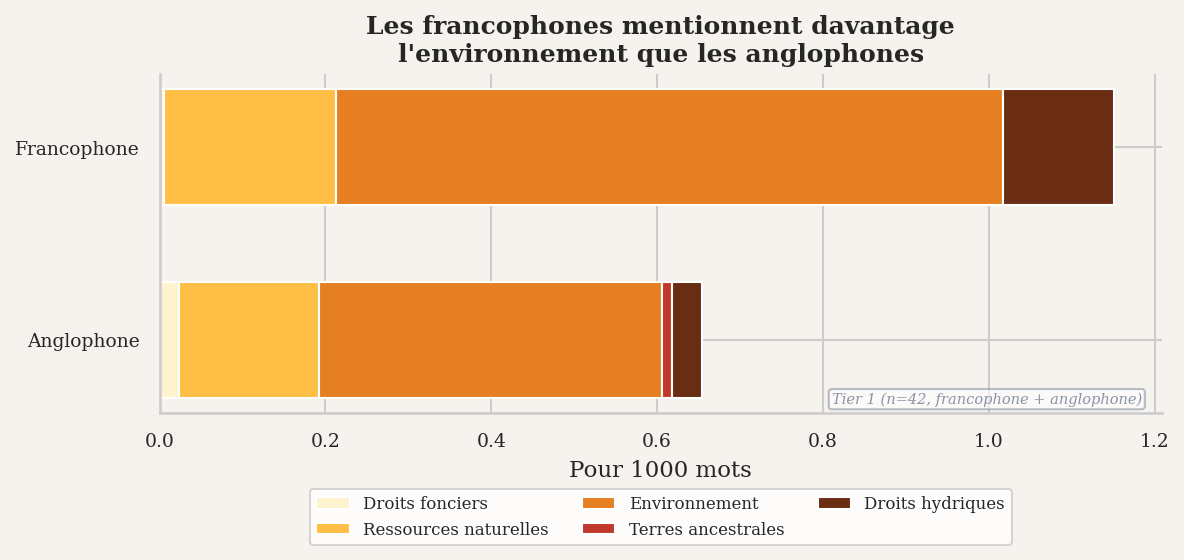

Saved: ch7_land_resources (fr + en)


In [7]:
# Load extended coding
with open(PROJECT_DIR / 'data' / 'extended_coding_v2.json') as f:
    ext_raw = json.load(f)
ext_df = pd.DataFrame(ext_raw['data'])

land_cols = ['land_tenure_per1k', 'natural_resources_per1k', 'environment_per1k',
             'water_per1k', 'territorial_integrity_per1k']

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Single-panel horizontal stacked bar by heritage — Tier 1 only
    h_order_left = ['francophone', 'anglophone']
    land_labels = t('ch7_land_cats', lang)
    colors_land = ['#fff3cd', '#ffbf47', '#e67e22', '#c0392b', '#6b2c14']

    for i, h in enumerate(h_order_left):
        subset = ext_df[ext_df['heritage'] == h]
        left = 0
        for j, col in enumerate(land_cols):
            val = subset[col].mean()
            ax.barh(i, val, left=left, color=colors_land[j], height=0.6,
                     label=land_labels[j] if i == 0 else None)
            left += val

    ax.set_yticks(range(len(h_order_left)))
    ax.set_yticklabels([hl(h, lang) for h in h_order_left])
    ax.set_xlabel(t('ch7_xlabel', lang))
    ax.set_title(t('ch7_title', lang), fontsize=12, fontweight='bold', fontfamily='serif')
    ax.legend(fontsize=8, loc='upper center', frameon=True, facecolor='white',
              bbox_to_anchor=(0.5, -0.2), ncol=3)
    ax.invert_yaxis()

    add_tier_note(ax, lang)

    fig.tight_layout()
    save_fig(fig, 'ch7_land_resources', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch7_land_resources (fr + en)')


## Figure G: Ch.8 — Cultural Rights Depth

Heatmap of cultural sub-categories by heritage group.

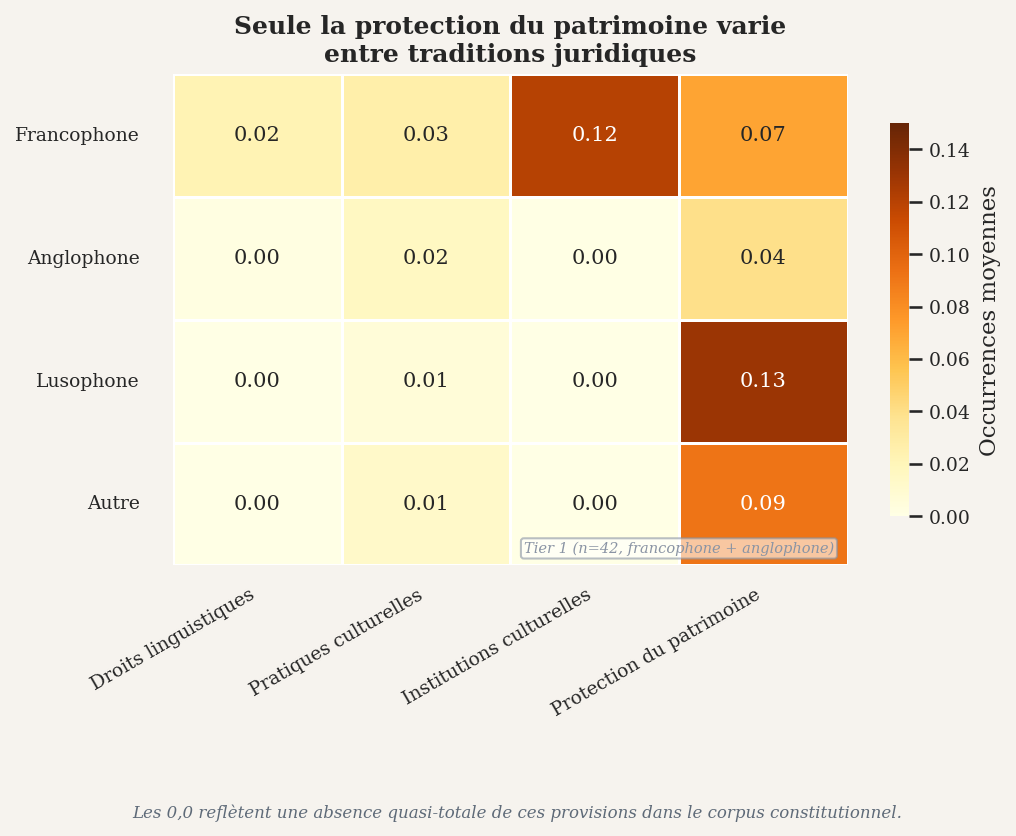

Saved: ch8_cultural_rights_depth (fr + en)


In [8]:
culture_cols_raw = ['language_official_per1k', 'cultural_practice_per1k',
                    'cultural_institution_per1k', 'cultural_heritage_per1k']

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(7, 5))

    h_order = ['francophone', 'anglophone', 'lusophone', 'other']
    matrix = []
    for h in h_order:
        subset = ext_df[ext_df['heritage'] == h]
        row = [subset[c].mean() for c in culture_cols_raw]
        matrix.append(row)

    matrix = np.array(matrix)
    cat_labels = t('ch8_cats', lang)
    h_labels = [hl(h, lang) for h in h_order]

    # Cap colorscale at 0.15 to show more variation in the low-value range
    sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlOrBr',
                vmin=0, vmax=0.15,
                xticklabels=cat_labels, yticklabels=h_labels,
                ax=ax, cbar_kws={'label': t('ch8_cbar', lang), 'shrink': 0.8},
                linewidths=0.5)

    ax.set_title(t('ch8_title', lang), fontsize=12, fontweight='bold', fontfamily='serif')
    plt.xticks(rotation=30, ha='right', fontsize=9)
    # Add padding between y-axis heritage names — prevent vertical overlap
    ax.set_yticklabels(h_labels, fontsize=9, rotation=0)
    ax.tick_params(axis='y', pad=10)
    fig.subplots_adjust(bottom=0.25, left=0.22)

    # Note explaining low values — this IS the finding
    fig.text(0.5, -0.1, t('ch8_zero_note', lang),
             ha='center', fontsize=8, color=C_MUTED, style='italic')

    add_tier_note(ax, lang)

    plt.tight_layout()
    save_fig(fig, 'ch8_cultural_rights_depth', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch8_cultural_rights_depth (fr + en)')


## Figure H: Ch.1 S2 — Semantic Composition of "peoples" Usage

Two horizontal 100%-stacked bars (francophone, anglophone) showing the semantic composition of "peoples" occurrences.

Total 'peoples' occurrences (Tier 1): 78
category     Charter citation  Diplomatic solidarity  Indigenous  \
heritage                                                           
anglophone                  0                      2           0   
francophone                20                     19           4   

category     National/domestic  
heritage                        
anglophone                  25  
francophone                  8  


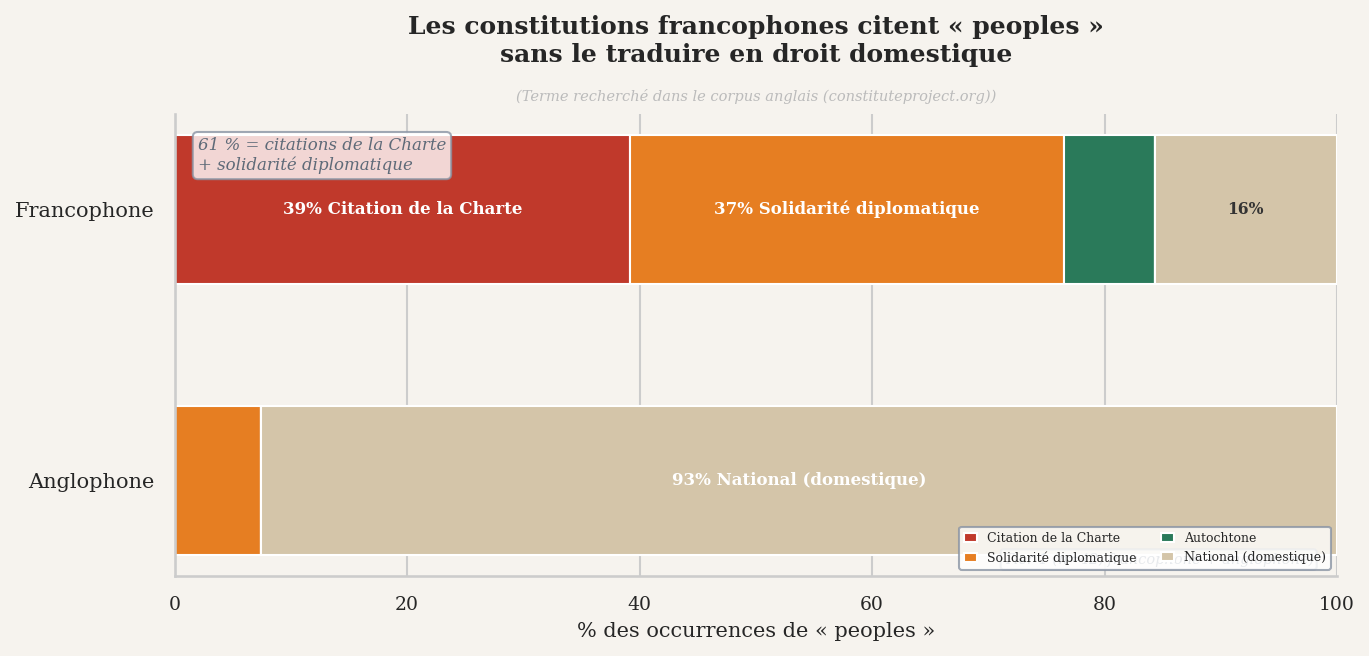

Saved: ch1s2_people_vs_peoples (fr + en)


In [9]:
# Load corpus data and classify each "peoples" occurrence by semantic context
import re as _re
from collections import Counter as _Counter

corpus_dir = PROJECT_DIR / 'data' / 'constitution_corpus'
heritage_map = DATA['colonial_heritage']

# Load country mapping
with open(PROJECT_DIR / 'scripts' / 'country_mapping.json') as f:
    country_mapping = json.load(f)

def classify_peoples(text_before, text_after):
    """Classify a 'peoples' occurrence by its surrounding context."""
    context = (text_before + ' ' + text_after).lower()
    if any(k in context for k in ['charter', 'charte', 'african charter']):
        return 'Charter citation'
    if any(k in context for k in ['world', 'africa', 'nations', 'brotherly', 'friendly', 'solidarity']):
        return 'Diplomatic solidarity'
    if any(k in context for k in ['indigenous', 'autochthon']):
        return 'Indigenous'
    if any(k in context for k in ['self-determination', 'autodetermination']):
        return 'Self-determination'
    if any(k in context for k in ["people's defence", 'updf', "people's republic"]):
        return 'Proper noun'
    return 'National/domestic'

# Collect all "peoples" occurrences with context window
ctx_rows = []
for txt_file in sorted(corpus_dir.glob('*.txt')):
    en_name = _re.sub(r'_\d{4}$', '', txt_file.stem).replace('_', ' ')
    fr_name = country_mapping.get(en_name)
    if not fr_name:
        continue
    h = heritage_map.get(fr_name, 'other')
    if h not in TIER1_HERITAGES:
        continue
    text = txt_file.read_text(errors='ignore')
    # Find all "peoples" with context (100 chars before and after)
    for m in _re.finditer(r'\bpeoples\b', text, flags=_re.IGNORECASE):
        start = max(0, m.start() - 100)
        end = min(len(text), m.end() + 100)
        before = text[start:m.start()]
        after = text[m.end():end]
        cat = classify_peoples(before, after)
        ctx_rows.append({'heritage': h, 'category': cat})

ctx_df = pd.DataFrame(ctx_rows)
print(f"Total 'peoples' occurrences (Tier 1): {len(ctx_df)}")
print(ctx_df.groupby(['heritage', 'category']).size().unstack(fill_value=0))

# Category order and label mapping
cat_order = ['Charter citation', 'Diplomatic solidarity', 'Indigenous',
             'Self-determination', 'Proper noun', 'National/domestic']
cat_label_keys = {
    'Charter citation': 'ctx_charter',
    'Diplomatic solidarity': 'ctx_diplomatic',
    'Indigenous': 'ctx_indigenous',
    'Self-determination': 'ctx_self_determination',
    'Proper noun': 'ctx_proper_noun',
    'National/domestic': 'ctx_national',
}
cat_colors = ['#c0392b', '#e67e22', '#2a7a5a', '#4a5a9a', '#8a94a4', '#d4c5a9']

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 4))

    h_order_2 = ['francophone', 'anglophone']
    for i, h in enumerate(h_order_2):
        sub = ctx_df[ctx_df['heritage'] == h]
        total = len(sub)
        if total == 0:
            continue
        counts = sub['category'].value_counts()
        left = 0
        for j, cat in enumerate(cat_order):
            n = counts.get(cat, 0)
            pct = n / total * 100
            ax.barh(i, pct, left=left, color=cat_colors[j], height=0.55)
            if pct >= 30:
                ax.text(left + pct / 2, i, f'{pct:.0f}% {t(cat_label_keys[cat], lang)}',
                        ha='center', va='center', fontsize=8, fontweight='bold', color='white')
            elif pct >= 10:
                ax.text(left + pct / 2, i, f'{pct:.0f}%',
                        ha='center', va='center', fontsize=7.5, fontweight='bold', color='#333')
            left += pct

    ax.set_yticks(range(len(h_order_2)))
    ax.set_yticklabels([hl(h, lang) for h in h_order_2], fontsize=10)
    ax.set_xlabel(t('peoples_semantic_xlabel', lang), fontsize=10)

    # Title (bold, large)
    ax.set_title(t('peoples_semantic_title', lang),
                 fontsize=12, fontweight='bold', fontfamily='serif', pad=25)

    # Subtitle (much lighter, smaller — clearly subordinate)
    ax.annotate('(' + t('people_vs_peoples_corpus_note', lang) + ')',
                xy=(0.5, 1.0), xycoords='axes fraction',
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7, color='#bbb', style='italic')

    ax.set_xlim(0, 100)
    ax.invert_yaxis()

    # Color legend as box in the empty space below anglophone bar
    from matplotlib.patches import Patch
    legend_handles = [Patch(facecolor=cat_colors[j], label=t(cat_label_keys[cat], lang))
                      for j, cat in enumerate(cat_order) if cat in ctx_df['category'].values]
    ax.legend(handles=legend_handles, loc='lower right',
              fontsize=6, frameon=True, facecolor='white', edgecolor=C_DIM,
              borderpad=0.4, handlelength=1.0, ncol=2)

    # Key annotation
    ax.text(0.02, 0.95, t('peoples_semantic_annot', lang), transform=ax.transAxes,
            ha='left', va='top', fontsize=8, color=C_MUTED, style='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=C_DIM, alpha=0.8))
    add_tier_note(ax, lang)

    save_fig(fig, 'ch1s2_people_vs_peoples', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch1s2_people_vs_peoples (fr + en)')


## Maps & Creative Visualizations

Geographic and non-traditional visualizations that make the thesis argument immediately visual.

In [10]:
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import mannwhitneyu

# Load Africa GeoDataFrame with scores
africa = load_africa_gdf(DATA)
print(f'Africa GDF: {len(africa)} features, {africa["country"].notna().sum()} matched')


Africa GDF: 54 features, 52 matched


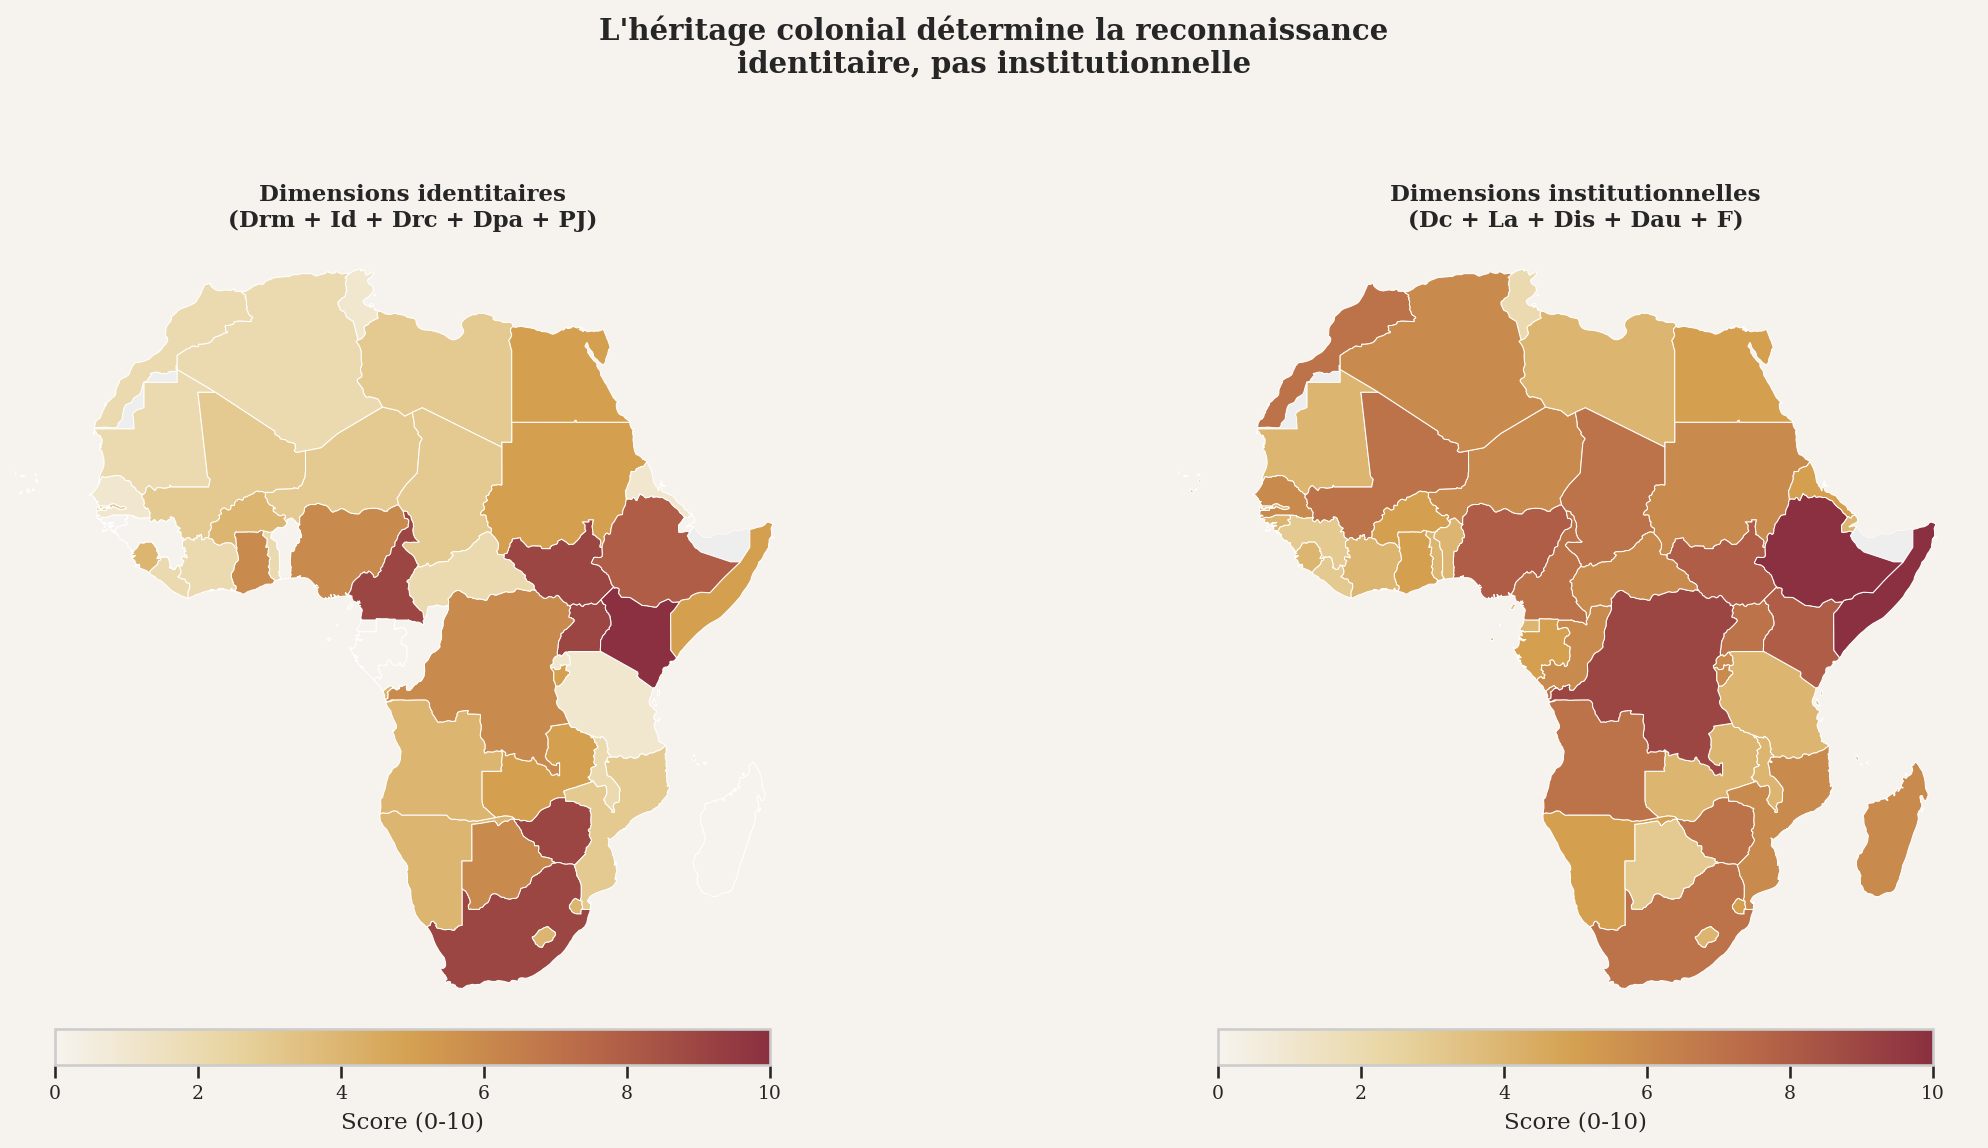

Saved: ch2s2_dual_choropleth (fr + en)


In [11]:
# Custom warm colormap matching academic palette
thesis_cmap = LinearSegmentedColormap.from_list('thesis',
    ['#f6f3ee', '#e8d4a0', '#d4a050', '#b86848', '#8a3040'])

for lang in ('fr', 'en'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    for ax, col, subtitle_key in [
        (ax1, 'identity_score', 'dual_choropleth_identity'),
        (ax2, 'institutional_score', 'dual_choropleth_institutional'),
    ]:
        # Background: all Africa in light gray
        africa.plot(ax=ax, color='#eee', edgecolor='white', linewidth=0.3)
        # Overlay: matched countries with score gradient
        matched = africa[africa['country'].notna()]
        matched.plot(ax=ax, column=col, cmap=thesis_cmap, edgecolor='white',
                     linewidth=0.5, vmin=0, vmax=10, legend=True,
                     legend_kwds={'label': t('choropleth_cbar', lang), 'shrink': 0.6,
                                  'orientation': 'horizontal', 'pad': 0.02})

        ax.set_title(t(subtitle_key, lang), fontsize=11, fontweight='bold', pad=8)
        ax.set_xlim(-25, 55)
        ax.set_ylim(-37, 40)
        ax.set_axis_off()

    fig.suptitle(t('dual_choropleth_title', lang), fontsize=14, fontweight='bold',
                 fontfamily='serif', y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    save_fig(fig, 'ch2s2_dual_choropleth', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch2s2_dual_choropleth (fr + en)')


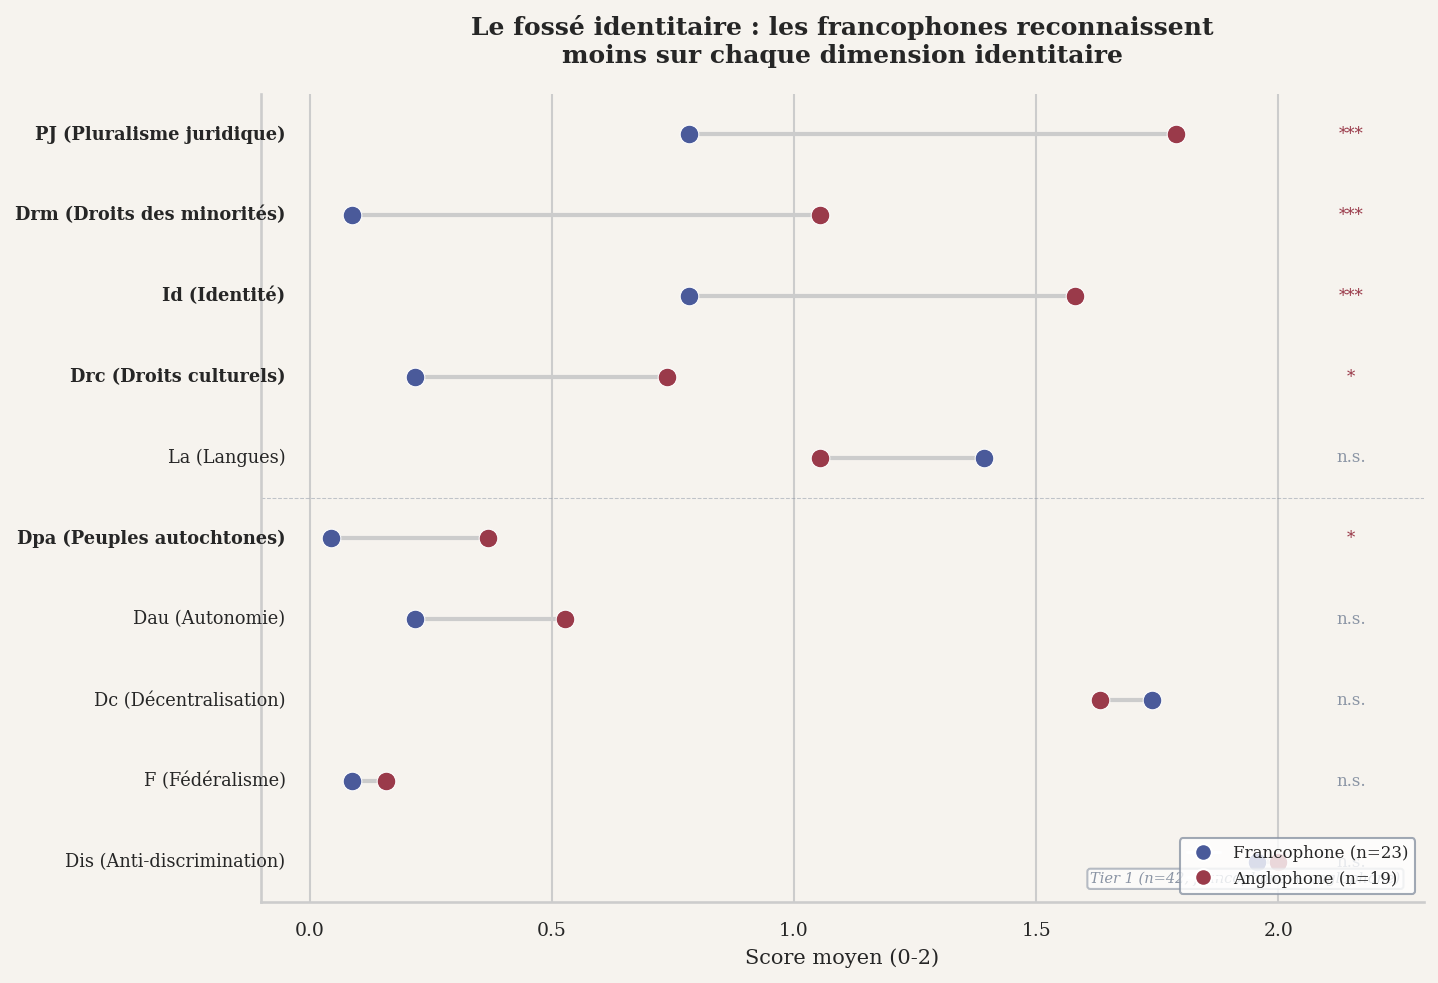

Saved: ch2s2_heritage_dumbbell (fr + en)


In [12]:
# Compute per-dimension means for franco vs anglo (Tier 1)
tier1 = fm[fm['heritage'].isin(TIER1_HERITAGES)].copy()
franco = tier1[tier1['heritage'] == 'francophone']
anglo = tier1[tier1['heritage'] == 'anglophone']

dim_stats = []
for feat in FEATURES:
    f_mean = franco[feat].mean()
    a_mean = anglo[feat].mean()
    gap = a_mean - f_mean
    stat, p = mannwhitneyu(franco[feat].values, anglo[feat].values, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    group = 'identity' if feat in IDENTITY_DIMS else 'institutional'
    dim_stats.append({'feat': feat, 'f_mean': f_mean, 'a_mean': a_mean,
                      'gap': gap, 'p': p, 'sig': sig, 'group': group})

# Sort by gap size descending
dim_stats.sort(key=lambda x: abs(x['gap']), reverse=True)

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(10, 7))

    for i, d in enumerate(dim_stats):
        y = len(dim_stats) - 1 - i
        # Connecting line
        ax.plot([d['f_mean'], d['a_mean']], [y, y], color='#ccc', linewidth=2, zorder=1)
        # Dots
        ax.scatter(d['f_mean'], y, color=HC['francophone'], s=80, zorder=3, edgecolors='white', linewidths=0.5)
        ax.scatter(d['a_mean'], y, color=HC['anglophone'], s=80, zorder=3, edgecolors='white', linewidths=0.5)
        # Dimension label
        label = f"{d['feat']} ({t('dim', lang)[d['feat']]})"
        ax.text(-0.05, y, label, ha='right', va='center', fontsize=8.5,
                fontweight='bold' if d['group'] == 'identity' else 'normal')
        # Significance
        ax.text(2.15, y, d['sig'], ha='center', va='center', fontsize=8,
                color=HC['anglophone'] if d['sig'] != 'n.s.' else C_DIM)

    # Separator between identity and institutional
    identity_count = sum(1 for d in dim_stats if d['group'] == 'identity')
    sep_y = len(dim_stats) - identity_count - 0.5
    ax.axhline(sep_y, color=C_DIM, linewidth=0.5, linestyle='--', alpha=0.5)

    ax.set_xlim(-0.1, 2.3)
    ax.set_ylim(-0.5, len(dim_stats) - 0.5)
    ax.set_yticks([])
    ax.set_xlabel(t('pc_mechanism_ylabel', lang), fontsize=10)
    ax.set_title(t('dumbbell_title', lang), fontsize=12, fontweight='bold',
                 fontfamily='serif', pad=15)

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=HC['francophone'],
               markersize=8, label=hl('francophone', lang) + f' (n={len(franco)})'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=HC['anglophone'],
               markersize=8, label=hl('anglophone', lang) + f' (n={len(anglo)})'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, frameon=True,
              facecolor='white', edgecolor=C_DIM)
    add_tier_note(ax, lang)

    save_fig(fig, 'ch2s2_heritage_dumbbell', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch2s2_heritage_dumbbell (fr + en)')


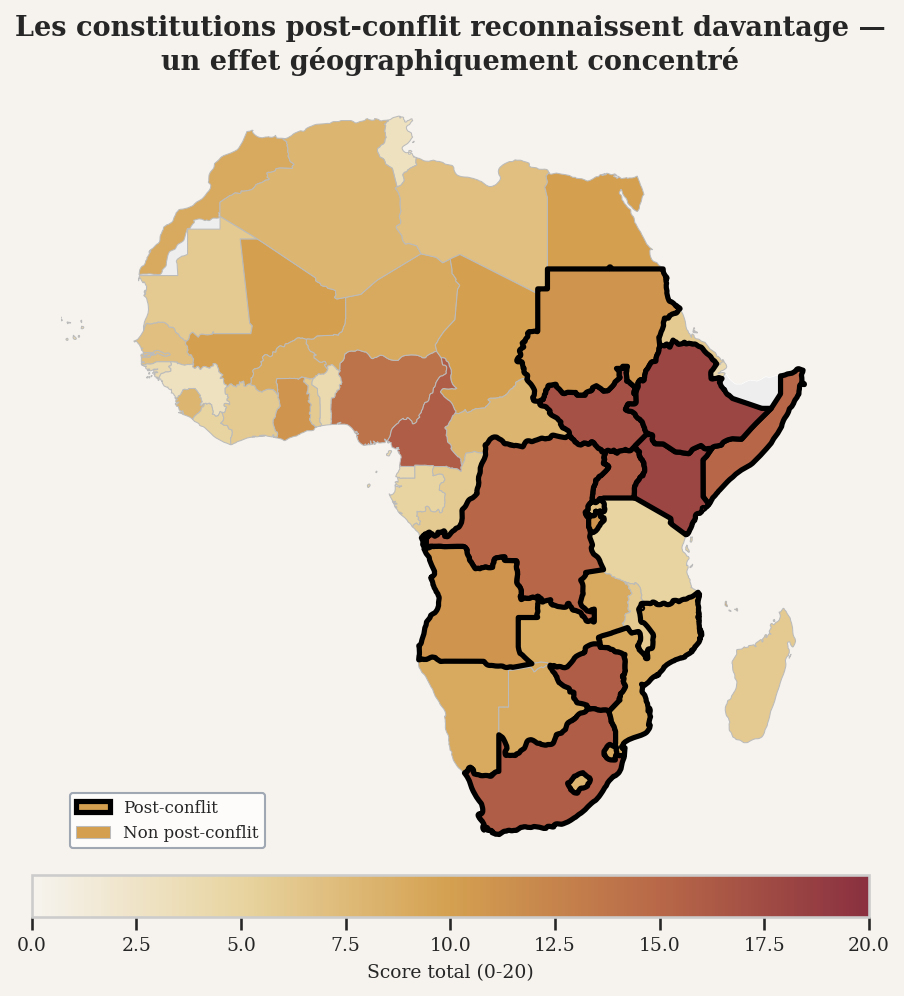

Saved: overview_choropleth_score (fr + en)


In [13]:
for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(12, 8))

    # Background Africa
    africa.plot(ax=ax, color='#eee', edgecolor='white', linewidth=0.3)

    # Non post-conflict countries
    matched = africa[africa['country'].notna()]
    npc = matched[matched['post_conflict'] != True]
    npc.plot(ax=ax, column='total_score', cmap=thesis_cmap, edgecolor='#bbb',
             linewidth=0.5, vmin=0, vmax=20)

    # Post-conflict countries: same gradient but thick black border
    pc = matched[matched['post_conflict'] == True]
    pc.plot(ax=ax, column='total_score', cmap=thesis_cmap, edgecolor='black',
            linewidth=2.5, vmin=0, vmax=20)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=thesis_cmap, norm=plt.Normalize(0, 20))
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, orientation='horizontal', pad=0.02)
    cbar.set_label(t('overview_choropleth_cbar', lang), fontsize=9)

    ax.set_title(t('overview_choropleth_title', lang), fontsize=13, fontweight='bold',
                 fontfamily='serif', pad=10)
    ax.set_xlim(-25, 55)
    ax.set_ylim(-37, 40)
    ax.set_axis_off()

    # Legend for border meaning
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d4a050', edgecolor='black', linewidth=2.5,
              label=t('overview_choropleth_pc', lang)),
        Patch(facecolor='#d4a050', edgecolor='#bbb', linewidth=0.5,
              label=t('overview_choropleth_npc', lang)),
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=8,
              frameon=True, facecolor='white', edgecolor=C_DIM)

    save_fig(fig, 'overview_choropleth_score', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: overview_choropleth_score (fr + en)')


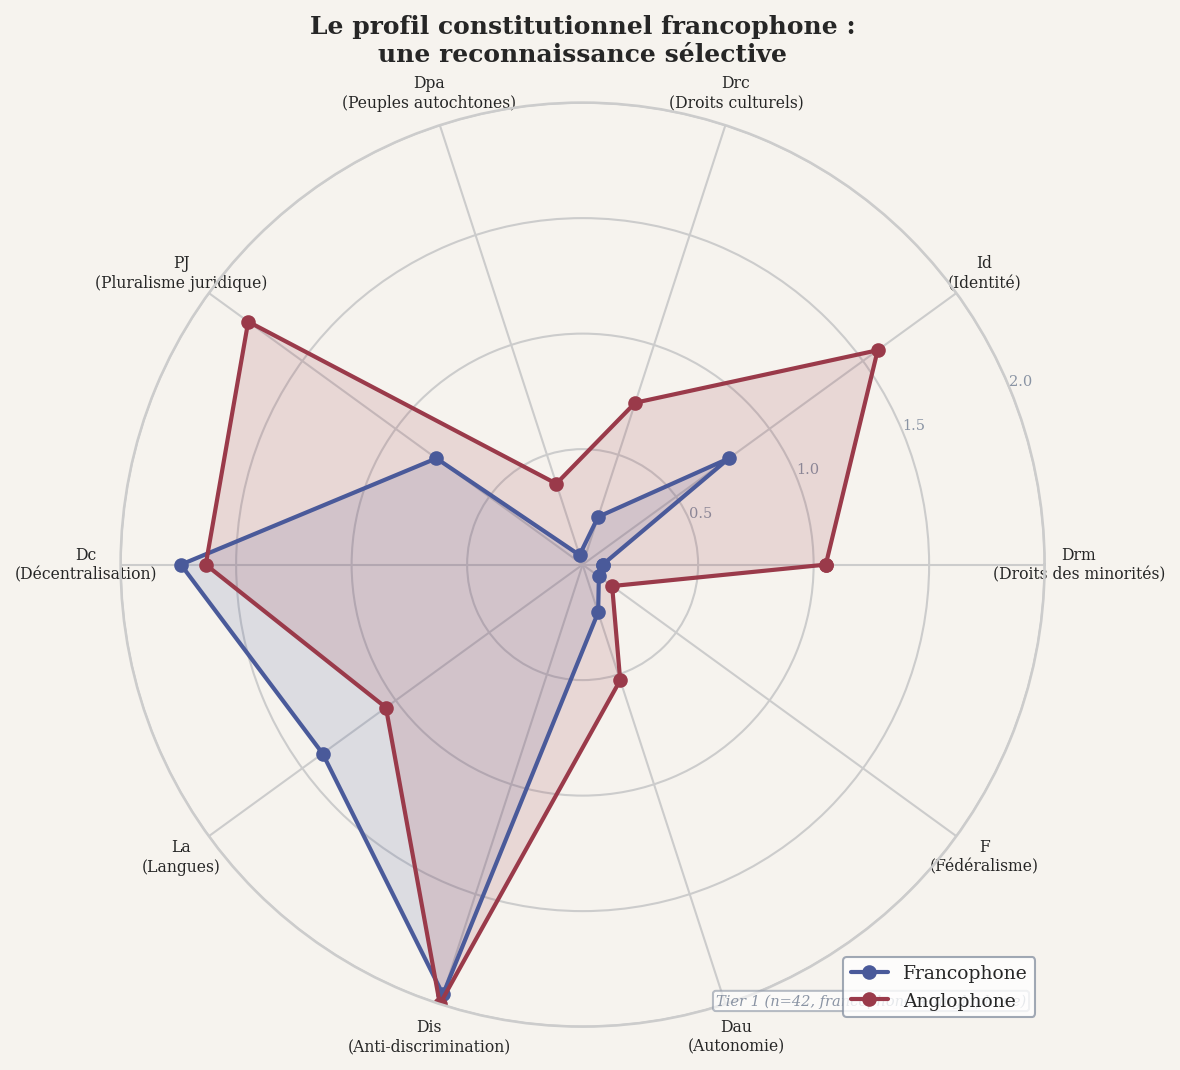

Saved: ch2s2_heritage_radar (fr + en)


In [14]:
# Radar chart: heritage profiles
# Order axes: identity dims on left, institutional on right
radar_dims = IDENTITY_DIMS + INSTITUTIONAL_DIMS

franco_means = [franco[f].mean() for f in radar_dims]
anglo_means = [anglo[f].mean() for f in radar_dims]

for lang in ('fr', 'en'):
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    n_dims = len(radar_dims)
    angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    f_vals = franco_means + franco_means[:1]
    a_vals = anglo_means + anglo_means[:1]

    ax.plot(angles, f_vals, 'o-', color=HC['francophone'], linewidth=2, label=hl('francophone', lang))
    ax.fill(angles, f_vals, color=HC['francophone'], alpha=0.15)
    ax.plot(angles, a_vals, 'o-', color=HC['anglophone'], linewidth=2, label=hl('anglophone', lang))
    ax.fill(angles, a_vals, color=HC['anglophone'], alpha=0.15)

    # Dimension labels
    dim_labels = [f"{f}\n({t('dim', lang)[f]})" for f in radar_dims]
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_labels, fontsize=7.5)

    ax.set_ylim(0, 2)
    ax.set_yticks([0.5, 1.0, 1.5, 2.0])
    ax.set_yticklabels(['0.5', '1.0', '1.5', '2.0'], fontsize=7, color=C_DIM)

    ax.set_title(t('radar_title', lang), fontsize=12, fontweight='bold',
                 fontfamily='serif', pad=20)
    ax.legend(loc='lower right', fontsize=9, frameon=True, facecolor='white',
              edgecolor=C_DIM)
    add_tier_note(ax, lang)

    save_fig(fig, 'ch2s2_heritage_radar', lang)
    if lang == 'fr': plt.show()
    else: plt.close(fig)

print('Saved: ch2s2_heritage_radar (fr + en)')


## Summary

In [15]:
import glob

print('=== Thesis Figures Generated ===')
for lang in ('fr', 'en'):
    figs = sorted(glob.glob(str(FIG_DIR / lang / '*.pdf')))
    print(f'\n{lang.upper()}: {len(figs)} PDFs')
    for f in figs:
        print(f'  {Path(f).name}')

=== Thesis Figures Generated ===

FR: 35 PDFs
  ch1s1_preamble_balance.pdf
  ch1s1_preamble_sovereignty_identity.pdf
  ch1s1_sovereignty_markers.pdf
  ch1s2_naming_heatmap.pdf
  ch1s2_people_vs_peoples.pdf
  ch1s2_peoples_context.pdf
  ch2s1_treaty_beeswarm.pdf
  ch2s2_correlation_matrix.pdf
  ch2s2_dual_choropleth.pdf
  ch2s2_heritage_divergence.pdf
  ch2s2_heritage_dumbbell.pdf
  ch2s2_heritage_radar.pdf
  ch2s2_score_distribution.pdf
  ch3_article_frequency.pdf
  ch3_case_law_timeline.pdf
  ch3_functional_criterion_emergence.pdf
  ch4_landmark_citations.pdf
  ch4s1_doctrinal_concepts.pdf
  ch4s2_cross_system_citations.pdf
  ch5_pre_post_ogiek.pdf
  ch5_sd_flags_heatmap.pdf
  ch5_self_determination_posture.pdf
  ch7_land_resources.pdf
  ch8_cultural_rights_depth.pdf
  clusters_dendrogram_dimensions.pdf
  clusters_similarity_heatmap.pdf
  clusters_umap_constitutions.pdf
  clusters_umap_preambles.pdf
  kwic_customary_context.pdf
  overview_choropleth_score.pdf
  post_conflict_dimension